# Category Encoders: Catalog & Experiments (Part 2)

We get 24 encoders from 4 libraries:

| library | one-hot encoders | other simple encoders | contrast encoders | target/Bayesian encoders |
| --- | --- | --- | --- | --- |
| [sklearn.preprocessing](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing) | OneHotEncoder | LabelEncoder <br> OrdinalEncoder <br> LabelBinarizer | |
| [category_encoders](https://contrib.scikit-learn.org/category_encoders) | OneHotEncoder | OrdinalEncoder <br> BinaryEncoder <br> BaseNEncoder <br> CountEncoder <br> **HashingEncoder** | HelmertEncoder <br> SumEncoder <br> BackwardDifferenceEncoder <br> **PolynomialEncoder** | **TargetEncoder <br> LeaveOneOutEncoder <br> CatBoostEncoder** <br> MEstimateEncoder <br> WOEEncoder <br> JamesSteinEncoder <br> GLMMEncoder |
| [pandas](https://pandas.pydata.org) | get_dummies | factorize | | |
| [keras.utils](https://keras.io/api/utils) | to_categorical | | | |


<br>This notebook explores step-by-step the Hashing Encoder, the Polynomial Encoder and some flavours/variations of the target encoder. All flavours of target encoders peeks into the target; we therefore need to be mindful of data leakage. Options are available to regulate/control data leakage and overfitting. *TargetEncoder* is the vanilla flavour. *LeaveOneOutEncoder* is the conservative option, where a given sample sees other samples' target but blindfolded from it's own. *CatBoostEncoder* is sensitive to row ordering; a given sample sees the target of preceding samples only. *JamesSteinEncoder* is for normal distributions.

In particular, we have in this notebook
* ```TargetEncoder``` (the vanilla form) demonstrated in detail to tell the principle behind target encoding, which underlies all flavours of target encoding. Manual back-of-envelop derivation is compared with automated output from ```TargetEncoder```.
* ```LeaveOneOutEncoder``` demonstrated in detail as a conservative step up to reduce data leakage and overfitting. Manual back-of-envelop derivation is compared with automated output from ```LeaveOneOutEncoder```.

<br> This notebook continues from an earlier notebook, [Category Encoders: Catalog & Experiments (Part 1)](https://www.kaggle.com/marychin/category-encoders-catalog-experiments-part-1).

<br>
When to use which encoder to solve what problems? There is a good guide here: [Encode Smarter: How to Easily Integrate Categorical Encoding into Your Machine Learning Pipeline](https://innovation.alteryx.com/encode-smarter).

In [1]:
from sklearn.preprocessing import LabelEncoder
from category_encoders import HashingEncoder, PolynomialEncoder
from category_encoders import TargetEncoder, LeaveOneOutEncoder, MEstimateEncoder, WOEEncoder, JamesSteinEncoder, CatBoostEncoder, GLMMEncoder
from keras import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, gc, time
warnings.simplefilter('ignore') # once | error | always | default | module

from tqdm import tqdm_notebook

# We shall be compiling a summary table as we go along.
summary = pd.DataFrame({'inp2out_map': pd.Series(dtype=object),   # input-to-output map
                        'nunique'    : pd.Series(dtype=int),      # number of unique (or distinct) values in output
                        'unique'     : pd.Series(dtype='object'), # unique values in output
                        'shape'      : pd.Series(dtype=int),      # rows-by-columns of output array
                        'tictoc'     : pd.Series(dtype=int)})     # computation time i seconds
summary.index.name = 'encoder'
# The grand summary is printed at the end of this notebook.

In [2]:
train = pd.read_csv('/kaggle/input/tabular-playground-series-mar-2021/train.csv', index_col='id')
train.sample(5)

,cat0,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,target
id,,,,,,,,,,,,,,,,,,,,,
495005,A,F,G,B,G,BI,A,AS,L,A,...,0.820074,0.789768,0.816454,0.485436,0.354946,0.976598,0.681087,0.814072,0.882138,0
243100,A,K,A,B,H,BI,A,S,S,A,...,0.772937,0.847923,0.685207,0.555308,0.256637,0.829050,0.674626,0.956554,0.943646,0
140636,A,K,A,D,E,BI,A,Y,BM,F,...,0.773493,0.850644,0.672056,0.620185,0.220673,0.957548,0.584683,0.728343,0.954403,0
290523,B,G,F,A,E,D,E,O,BB,A,...,0.328687,0.272890,0.401793,0.169060,0.466847,0.432257,0.364324,0.479719,0.383629,0
472078,A,L,C,A,F,BI,A,K,H,A,...,0.496900,0.247511,0.711942,0.785559,0.587615,0.467987,0.481061,0.423949,0.469969,0


In [3]:
# Let's zoom into a single column.
train['cat10'].nunique(), train['cat10'].unique()
# cat10 alone has 299 unique values altogether. This value in termed 'cardinality'.
# This is an extreme case. Cardinalities are usually lower e.g. exam grades = A, B, C, D, E would have cardinality=5.

(299,
 array(['LO', 'HJ', 'DJ', 'KV', 'DP', 'GE', 'HQ', 'HC', 'EK', 'GS', 'HG',
        'BY', 'HX', 'JK', 'FJ', 'LM', 'HK', 'MD', 'IG', 'JG', 'AN', 'AD',
        'MC', 'KW', 'CK', 'LF', 'CS', 'GK', 'DC', 'LB', 'FM', 'IH', 'LN',
        'IK', 'DF', 'IB', 'CB', 'LY', 'JW', 'FI', 'CR', 'IE', 'LE', 'HB',
        'HV', 'LG', 'BG', 'KP', 'LI', 'HL', 'BF', 'LU', 'O', 'GI', 'DQ',
        'IR', 'DV', 'HA', 'KB', 'FP', 'AT', 'IF', 'HN', 'GC', 'C', 'KC',
        'G', 'JA', 'CU', 'BC', 'AB', 'KF', 'MB', 'HE', 'BL', 'FQ', 'IA',
        'MJ', 'FO', 'V', 'JT', 'AU', 'IO', 'GQ', 'CC', 'JR', 'BM', 'HH',
        'AV', 'GT', 'I', 'IU', 'JN', 'EV', 'MV', 'EQ', 'LW', 'FN', 'IT',
        'AA', 'DK', 'IJ', 'GU', 'P', 'JH', 'CM', 'GA', 'R', 'LX', 'IX',
        'DY', 'D', 'FL', 'CP', 'GL', 'DI', 'CD', 'IV', 'FS', 'FR', 'J',
        'MP', 'MH', 'EL', 'JD', 'AP', 'AE', 'F', 'LC', 'BP', 'BI', 'MF',
        'DO', 'MG', 'MT', 'LD', 'CW', 'KS', 'BV', 'JV', 'BB', 'AM', 'KX',
        'FK', 'AH', 'LV', 'W', 'DU', 'FB',

In [4]:
# Now pick another column; just to have a look.
train['cat5'].nunique(), train['cat5'].unique()
# Lower cardinality in this column; 84 only.

(84,
 array(['BI', 'AB', 'BU', 'M', 'T', 'K', 'L', 'CG', 'BG', 'CI', 'N', 'G',
        'X', 'Q', 'O', 'BO', 'BB', 'BX', 'AF', 'BA', 'BQ', 'CA', 'D', 'AQ',
        'AS', 'AW', 'BE', 'CK', 'AL', 'BK', 'AT', 'CL', 'C', 'CF', 'I',
        'AH', 'CD', 'AY', 'BY', 'F', 'AI', 'R', 'BC', 'BH', 'AA', 'V',
        'CE', 'BD', 'AE', 'U', 'AU', 'AP', 'CJ', 'AN', 'AX', 'AR', 'BL',
        'J', 'ZZ', 'BR', 'BV', 'H', 'A', 'CC', 'P', 'CH', 'BJ', 'CB', 'BS',
        'BN', 'AO', 'AJ', 'BT', 'S', 'E', 'Y', 'AK', 'AM', 'B', 'BM', 'AV',
        'AG', 'BF', 'BP'], dtype=object))

# 1. Hashing Encoder
What is a Hashing Encoder? The question becomes immediately self-explanatory the moment we read the word ```hashing``` in the light of [MD5, SHA, ...](https://en.wikipedia.org/wiki/Secure_Hash_Algorithms). Yes, it's that same ```hash``` that the hashing encoder is about. 

```HashingEncoder``` takes ```n_components``` as an argument. Let us do a test with ```n_components```= 8, 16, 32:

In [5]:
%%time
for n_components in [8, 16, 32]:
    inp = train['cat10']
    tic = time.time()
    out = HashingEncoder(n_components=n_components).fit_transform(inp)
    tictoc = time.time() - tic

    inp2out_map = pd.concat([pd.DataFrame({'inp': train['cat10']}, columns=['inp']),
                             pd.DataFrame(out, index=train.index)], axis=1).drop_duplicates()
    inp2out_map.set_index('inp', inplace=True, drop=True)
    unik = np.unique(inp2out_map.values)
    summary.loc[f'HashingEncoder, {n_components}'] = inp2out_map, len(unik), unik, inp2out_map.shape, tictoc
columns_show = ['nunique', 'unique', 'shape', 'tictoc']
summary[columns_show]
# We find that no matter what n_components we asked for, the mapped values always consist of 0 and 1, and nothing else.
# When we ask for n_components=8, we get 8 columns in the output. When we ask for n_components=16, we get 16 columns. When we ask for n_components=32, we get 32 columns.

CPU times: user 932 ms, sys: 1.2 s, total: 2.13 s
Wall time: 6min 56s


,nunique,unique,shape,tictoc
encoder,,,,
"HashingEncoder, 8",2306,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...","(2215, 8)",134.535710
"HashingEncoder, 16",4610,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...","(3672, 16)",137.378554
"HashingEncoder, 32",9218,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...","(5634, 32)",144.150516


In [6]:
summary.loc['HashingEncoder, 8', 'inp2out_map']
# Some rows in inp2out_map contain null values. 
# This shows that some categories in the original input (train['cat10']) are not mapped to anything. 
# HashingEncoder therefore doesn't map one-to-one i.e. some of the original info is lost in the encoding process.

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
inp,,,,,,,,
LO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
HJ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DJ,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KV,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DP,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
MU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Now we filter out the null rows and show only non-null rows.
non_null_idx = ~summary.loc['HashingEncoder, 8', 'inp2out_map'].isnull().any(axis=1)
non_null_rows = summary.loc['HashingEncoder, 8', 'inp2out_map'].loc[non_null_idx]
non_null_rows

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
inp,,,,,,,,
LO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
HJ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DJ,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KV,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DP,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
CT,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
GF,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
KI,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [8]:
# Next, we see if there are any duplicate rows that can be removed.
non_null_rows.drop_duplicates()
# We are left with just 8 rows! That means many input categories got mapped to the same output value. This loss of info is called *collision*.

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
inp,,,,,,,,
LO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DJ,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DP,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
GE,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
GS,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
HG,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
LM,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
DJ,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
# Let's repeat what we did in the previous two cells for ```n_components``` = 8, 16, 32:
print('{:15s}{}'.format('n_components', 'unique values of output'))
for n_components in [8, 16, 32]:
    non_null_idx = ~summary.loc[f'HashingEncoder, {n_components}', 'inp2out_map'].isnull().any(axis=1)
    non_null_rows = summary.loc[f'HashingEncoder, {n_components}', 'inp2out_map'].loc[non_null_idx]
    print('{:<15d}{}'.format(n_components, len(non_null_rows.drop_duplicates())))
# The lower number of unique values of output, the higher the collisions i.e. we suffer a greater info loss.

n_components   unique values of output
8              8
16             16
32             32


# 2. Polynomial encoder

In [10]:
inp = train['cat5']
tic = time.time()
out = PolynomialEncoder().fit_transform(inp)
tictoc = time.time() - tic

inp2out_map = pd.concat([pd.DataFrame({'inp': train['cat5']}, columns=['inp']),
                         pd.DataFrame(out, index=train.index)], axis=1).drop_duplicates()
inp2out_map.set_index('inp', inplace=True, drop=True)
unik = np.unique(inp2out_map.values)
summary.loc['PolynomialEncoder'] = inp2out_map, len(unik), unik, inp2out_map.shape, tictoc
summary.loc['PolynomialEncoder', 'inp2out_map']
# As shown in [Part 1](https://www.kaggle.com/marychin/category-encoders-catalog-experiments-part-1) of this notebook series, contrast encoders output an ```intercept``` column.

,intercept,cat5_0,cat5_1,cat5_2,cat5_3,cat5_4,cat5_5,cat5_6,cat5_7,cat5_8,...,cat5_73,cat5_74,cat5_75,cat5_76,cat5_77,cat5_78,cat5_79,cat5_80,cat5_81,cat5_82
inp,,,,,,,,,,,,,,,,,,,,,
BI,1,-0.186746,0.235414,-0.268769,0.290573,-0.302656,0.306302,-0.302656,0.292847,-0.278024,...,1.770806e-10,7.299750e-12,1.712916e-10,-2.854704e-10,6.120742e-12,-6.032872e-12,3.831999e-11,2.760232e-12,8.613030e-12,-1.932175e-11
AB,1,-0.182246,0.218396,-0.229911,0.220556,-0.193262,0.151306,-0.098454,0.038811,0.023448,...,-7.291329e-09,-5.781240e-10,-7.119583e-09,1.233888e-08,-3.021119e-10,2.365063e-10,-1.678799e-09,-1.296780e-10,-4.288247e-10,8.985556e-10
BU,1,-0.177746,0.201793,-0.193422,0.158223,-0.102545,0.034114,0.038510,-0.106795,0.163154,...,1.418400e-07,1.728488e-08,1.395434e-07,-2.523643e-07,7.260304e-09,-4.305164e-09,3.461148e-08,2.824324e-09,1.012065e-08,-1.974676e-08
M,1,-0.173246,0.185606,-0.159244,0.103132,-0.028661,-0.050875,0.122072,-0.173421,0.197014,...,-1.728053e-06,-2.938807e-07,-1.709330e-06,3.241028e-06,-1.121706e-07,4.797201e-08,-4.448470e-07,-3.785594e-08,-1.502562e-07,2.720492e-07
T,1,-0.168746,0.169833,-0.127319,0.054852,0.030132,-0.108737,0.164165,-0.184996,0.167316,...,1.472572e-05,3.323298e-06,1.461105e-05,-2.923636e-05,1.240550e-06,-3.621500e-07,3.976710e-06,3.495880e-07,1.570158e-06,-2.627014e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BM,1,0.168746,0.169833,0.127319,0.054852,-0.030132,-0.108737,-0.164165,-0.184996,-0.167316,...,1.512632e-05,1.747659e-05,2.366996e-05,2.726062e-06,1.287446e-05,9.886731e-06,1.898541e-06,9.074773e-07,-5.329158e-07,1.488154e-06
AV,1,0.173246,0.185606,0.159244,0.103132,0.028661,-0.050875,-0.122072,-0.173421,-0.197014,...,-1.660026e-06,-1.959109e-06,-2.600836e-06,-3.292415e-07,-1.352248e-06,-1.012270e-06,-1.993582e-07,-1.017002e-07,4.747337e-08,-1.335518e-07
AG,1,0.177746,0.201793,0.193422,0.158223,0.102545,0.034114,-0.038510,-0.106795,-0.163154,...,1.286915e-07,1.543543e-07,2.021548e-07,2.755137e-08,1.002400e-07,7.334658e-08,1.483640e-08,7.966972e-09,-2.950411e-09,8.443896e-09


In [11]:
# Now we filter out the null rows and show only non-null rows.
non_null_idx = ~summary.loc['PolynomialEncoder', 'inp2out_map'].isnull().any(axis=1)
non_null_rows = summary.loc['PolynomialEncoder', 'inp2out_map'].loc[non_null_idx]
non_null_rows

,intercept,cat5_0,cat5_1,cat5_2,cat5_3,cat5_4,cat5_5,cat5_6,cat5_7,cat5_8,...,cat5_73,cat5_74,cat5_75,cat5_76,cat5_77,cat5_78,cat5_79,cat5_80,cat5_81,cat5_82
inp,,,,,,,,,,,,,,,,,,,,,
BI,1,-0.186746,0.235414,-0.268769,0.290573,-0.302656,0.306302,-0.302656,0.292847,-0.278024,...,1.770806e-10,7.299750e-12,1.712916e-10,-2.854704e-10,6.120742e-12,-6.032872e-12,3.831999e-11,2.760232e-12,8.613030e-12,-1.932175e-11
AB,1,-0.182246,0.218396,-0.229911,0.220556,-0.193262,0.151306,-0.098454,0.038811,0.023448,...,-7.291329e-09,-5.781240e-10,-7.119583e-09,1.233888e-08,-3.021119e-10,2.365063e-10,-1.678799e-09,-1.296780e-10,-4.288247e-10,8.985556e-10
BU,1,-0.177746,0.201793,-0.193422,0.158223,-0.102545,0.034114,0.038510,-0.106795,0.163154,...,1.418400e-07,1.728488e-08,1.395434e-07,-2.523643e-07,7.260304e-09,-4.305164e-09,3.461148e-08,2.824324e-09,1.012065e-08,-1.974676e-08
M,1,-0.173246,0.185606,-0.159244,0.103132,-0.028661,-0.050875,0.122072,-0.173421,0.197014,...,-1.728053e-06,-2.938807e-07,-1.709330e-06,3.241028e-06,-1.121706e-07,4.797201e-08,-4.448470e-07,-3.785594e-08,-1.502562e-07,2.720492e-07
T,1,-0.168746,0.169833,-0.127319,0.054852,0.030132,-0.108737,0.164165,-0.184996,0.167316,...,1.472572e-05,3.323298e-06,1.461105e-05,-2.923636e-05,1.240550e-06,-3.621500e-07,3.976710e-06,3.495880e-07,1.570158e-06,-2.627014e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BM,1,0.168746,0.169833,0.127319,0.054852,-0.030132,-0.108737,-0.164165,-0.184996,-0.167316,...,1.512632e-05,1.747659e-05,2.366996e-05,2.726062e-06,1.287446e-05,9.886731e-06,1.898541e-06,9.074773e-07,-5.329158e-07,1.488154e-06
AV,1,0.173246,0.185606,0.159244,0.103132,0.028661,-0.050875,-0.122072,-0.173421,-0.197014,...,-1.660026e-06,-1.959109e-06,-2.600836e-06,-3.292415e-07,-1.352248e-06,-1.012270e-06,-1.993582e-07,-1.017002e-07,4.747337e-08,-1.335518e-07
AG,1,0.177746,0.201793,0.193422,0.158223,0.102545,0.034114,-0.038510,-0.106795,-0.163154,...,1.286915e-07,1.543543e-07,2.021548e-07,2.755137e-08,1.002400e-07,7.334658e-08,1.483640e-08,7.966972e-09,-2.950411e-09,8.443896e-09


In [12]:
# Next, we see if there are any duplicate rows that can be removed.
non_null_rows.drop_duplicates()
# We get 84 rows still. No collision in this case (unlike HashingEncoder).

,intercept,cat5_0,cat5_1,cat5_2,cat5_3,cat5_4,cat5_5,cat5_6,cat5_7,cat5_8,...,cat5_73,cat5_74,cat5_75,cat5_76,cat5_77,cat5_78,cat5_79,cat5_80,cat5_81,cat5_82
inp,,,,,,,,,,,,,,,,,,,,,
BI,1,-0.186746,0.235414,-0.268769,0.290573,-0.302656,0.306302,-0.302656,0.292847,-0.278024,...,1.770806e-10,7.299750e-12,1.712916e-10,-2.854704e-10,6.120742e-12,-6.032872e-12,3.831999e-11,2.760232e-12,8.613030e-12,-1.932175e-11
AB,1,-0.182246,0.218396,-0.229911,0.220556,-0.193262,0.151306,-0.098454,0.038811,0.023448,...,-7.291329e-09,-5.781240e-10,-7.119583e-09,1.233888e-08,-3.021119e-10,2.365063e-10,-1.678799e-09,-1.296780e-10,-4.288247e-10,8.985556e-10
BU,1,-0.177746,0.201793,-0.193422,0.158223,-0.102545,0.034114,0.038510,-0.106795,0.163154,...,1.418400e-07,1.728488e-08,1.395434e-07,-2.523643e-07,7.260304e-09,-4.305164e-09,3.461148e-08,2.824324e-09,1.012065e-08,-1.974676e-08
M,1,-0.173246,0.185606,-0.159244,0.103132,-0.028661,-0.050875,0.122072,-0.173421,0.197014,...,-1.728053e-06,-2.938807e-07,-1.709330e-06,3.241028e-06,-1.121706e-07,4.797201e-08,-4.448470e-07,-3.785594e-08,-1.502562e-07,2.720492e-07
T,1,-0.168746,0.169833,-0.127319,0.054852,0.030132,-0.108737,0.164165,-0.184996,0.167316,...,1.472572e-05,3.323298e-06,1.461105e-05,-2.923636e-05,1.240550e-06,-3.621500e-07,3.976710e-06,3.495880e-07,1.570158e-06,-2.627014e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BM,1,0.168746,0.169833,0.127319,0.054852,-0.030132,-0.108737,-0.164165,-0.184996,-0.167316,...,1.512632e-05,1.747659e-05,2.366996e-05,2.726062e-06,1.287446e-05,9.886731e-06,1.898541e-06,9.074773e-07,-5.329158e-07,1.488154e-06
AV,1,0.173246,0.185606,0.159244,0.103132,0.028661,-0.050875,-0.122072,-0.173421,-0.197014,...,-1.660026e-06,-1.959109e-06,-2.600836e-06,-3.292415e-07,-1.352248e-06,-1.012270e-06,-1.993582e-07,-1.017002e-07,4.747337e-08,-1.335518e-07
AG,1,0.177746,0.201793,0.193422,0.158223,0.102545,0.034114,-0.038510,-0.106795,-0.163154,...,1.286915e-07,1.543543e-07,2.021548e-07,2.755137e-08,1.002400e-07,7.334658e-08,1.483640e-08,7.966972e-09,-2.950411e-09,8.443896e-09


# 3. Target Encoders

In [13]:
feature = 'cat5'
for which in [TargetEncoder, LeaveOneOutEncoder, MEstimateEncoder, WOEEncoder, JamesSteinEncoder, GLMMEncoder, CatBoostEncoder]:
#   Grab the label, apply some minor hiding cosmetics:
    label = str(which).split('.')[-1].split("'")[0]

    tic = time.time()
    out = which().fit_transform(train[feature], train['target'])
    tictoc = time.time() - tic
    inp2out_map = pd.concat([pd.DataFrame({'inp': train[feature]}, columns=['inp']),
                             pd.DataFrame(out, index=train.index)], axis=1).drop_duplicates()
    inp2out_map.set_index('inp', inplace=True, drop=True)
    unik = np.unique(inp2out_map.values)
    summary.loc[label] = inp2out_map, len(unik), unik, inp2out_map.shape, tictoc

#   Test if encoding depends on the order of rows.
    shuffled = train[[feature, 'target']].copy()
    shuffled = shuffled.sample(frac=1)
    out_shuffled = which().fit_transform(shuffled[feature], shuffled['target'])
    out.rename(columns={feature: 'tis'}, inplace=True)
    out_shuffled.rename(columns={feature: 'tat'}, inplace=True)
    tistat = pd.concat([out, out_shuffled], names=['tis', 'tat'], axis=1)
    if not np.allclose(tistat['tis'], tistat['tat']):
        print(label, 'is order-dependent.')
columns_show = ['nunique', 'unique', 'shape', 'tictoc']
summary[columns_show]
# Output reports that GLMMEncoder and CatBoostEncoder depend on the order of rows.

GLMMEncoder is order-dependent.
CatBoostEncoder is order-dependent.


,nunique,unique,shape,tictoc
encoder,,,,
"HashingEncoder, 8",2306,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...","(2215, 8)",134.535710
"HashingEncoder, 16",4610,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...","(3672, 16)",137.378554
"HashingEncoder, 32",9218,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...","(5634, 32)",144.150516
PolynomialEncoder,6958,"[-0.430633330144245, -0.4053886884348236, -0.3...","(84, 84)",1.310252
TargetEncoder,80,"[0.0, 4.978516598974636e-13, 9.999202086330428...","(84, 1)",0.221409
LeaveOneOutEncoder,143,"[0.0, 0.007194244604316547, 0.0079365079365079...","(160, 1)",0.320637
MEstimateEncoder,83,"[0.004489322033898305, 0.006159767441860465, 0...","(84, 1)",0.208427
WOEEncoder,82,"[-3.0567453297795897, -2.911033518598196, -2.8...","(84, 1)",0.241502
JamesSteinEncoder,77,"[0.0, 0.02173629837498734, 0.03088899160954961...","(84, 1)",0.215459


# 3.1 Target Encoder (vanilla)

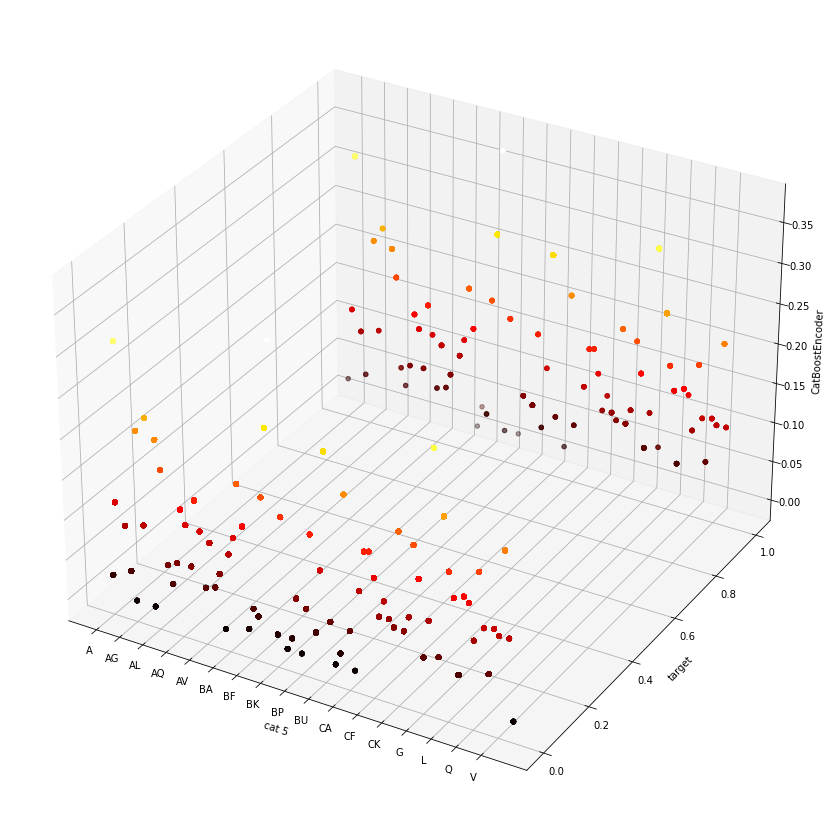

In [14]:
ncoda = LabelEncoder()
x = ncoda.fit_transform(train['cat5'])
y = train['target']
z = TargetEncoder().fit_transform(train['cat5'], train['target'])

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection='3d')
ax.scatter3D(x, y, z, c=z, cmap='hot')
ax.set_xlabel('cat 5'); ax.set_ylabel('target'); ax.set_zlabel(label)
_ = ax.set_xticks(np.arange(0, len(ncoda.classes_), 5))
_ = ax.set_xticklabels(ncoda.classes_[::5])
# 3D plot shows how encoders output depends on both cat5 and target.

In [15]:
# How does TargetEncoder encode? It takes the mean of the target of the given category.
# Let's have a goal doing this manually, then compare with TargetEncoder's output.
manual_auto = pd.DataFrame( {'manual': train.groupby('cat5')['target'].mean()} )
manual_auto = pd.concat([manual_auto, summary.loc['TargetEncoder', 'inp2out_map']], axis=1)
np.allclose(manual_auto['manual'], manual_auto['cat5'], atol=1e-7)
# So it is confirmed that our manual back-of-envelop calculation agrees with the output by TargetEncoder.

True

# 3.2 Leave-One-Out Encoder
LeaveOneOutEncoder is the conservative step up from the vanilla TargetEncoder. It reduces data leakage and overfitting by taking the target mean from rows other than a given row. A worked back-of-envelop example would explain best:

  0%|          | 0/78 [00:00<?, ?it/s]

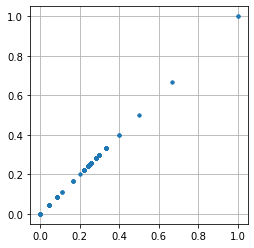

In [16]:
# train contains too many rows. To avoid prohibitive runtimes let's reduce train to a manageable subset.
reduced = train.sample(10000, random_state=77).reset_index(drop=True)

# Now let us try encoding leave-one-out manually.
manual = pd.Series()
for grp_idx, grp_data in tqdm_notebook(reduced.groupby('cat5'), total=reduced['cat5'].nunique()):
    for row_idx, row_data in grp_data.iterrows():
        manual.loc[row_idx] = grp_data.drop(row_idx)['target'].mean()
manual.name = 'loo_manual'
reduced = pd.concat([reduced, manual], axis=1)
reduced['loo_auto'] = LeaveOneOutEncoder().fit_transform(reduced['cat5'], reduced['target'])
plt.plot(reduced['loo_auto'], reduced['loo_manual'], '.'); plt.axis('square'); plt.grid(True)
# Looks good. Eyeballing the plot suggests good agreement between our manual encoding and LeaveOneOutEncoder's output.

In [17]:
# Next, put the comparison through a quantitative litmus test.
np.allclose(reduced['loo_auto'].values, reduced['loo_manual'].values, atol=1)
# It fails the litmus test. There is disagreement that escaped eyeballing of the plot in the previous cell.

False

In [18]:
# First suspect: null values?
reduced.loc[reduced['loo_manual'].isnull(), 'cat5']
# Indeed, that's the culprit.

108     BF
1083    BX
2223    CC
2329    AM
2956    BM
3827     R
4114     B
5235     J
6985    CG
8167    CB
8372    BJ
9533    BH
9687     P
Name: cat5, dtype: object

In [19]:
# Next line of investigation: where do those null values originate from?
pblem_grp = reduced.loc[reduced['loo_manual'].isnull(), 'cat5'].values
reduced['cat5'].value_counts().loc[pblem_grp]
# They are from category groups which exist only on a single row. 
# Our manual calculation was correct, because by definition it is not possible to encode Leave-One-Out for category groups with count=1. 
# That's because by definition in Leave-One-Out encoding a given row leaves itself out, in this case it is left with no row.

BF    1
BX    1
CC    1
AM    1
BM    1
R     1
B     1
J     1
CG    1
CB    1
BJ    1
BH    1
P     1
Name: cat5, dtype: int64

In [20]:
# So how did LeaveOneOutEncoder get a non-null value?
reduced.loc[reduced['cat5'].isin(pblem_grp)][['target', 'loo_manual', 'loo_auto']]
# So LeaveOneOutEncoder plugs in as surrogate a constant value it found somewhere, 0.2626.

,target,loo_manual,loo_auto
108,0,NaN,0.2626
1083,0,NaN,0.2626
2223,0,NaN,0.2626
2329,0,NaN,0.2626
2956,0,NaN,0.2626
3827,0,NaN,0.2626
4114,0,NaN,0.2626
5235,0,NaN,0.2626
6985,1,NaN,0.2626
8167,0,NaN,0.2626


In [21]:
# Let us make a wild guess where LeaveOneOutEncoder found the value 0.2626.
reduced['target'].mean()
# Voila.

0.2626